In [32]:
#IMPORT DA GOOD STUFF
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import perf_counter

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [33]:
#LOAD DA DATA
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (630000, 21)
Test shape: (270000, 20)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [34]:
#SHOW DA DATA
print("=== Column Types ===")
print(train.dtypes)

=== Column Types ===
id                           int64
Soil_Type                      str
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                      str
Crop_Growth_Stage              str
Season                         str
Irrigation_Type                str
Water_Source                   str
Field_Area_hectare         float64
Mulching_Used                  str
Previous_Irrigation_mm     float64
Region                         str
Irrigation_Need                str
dtype: object


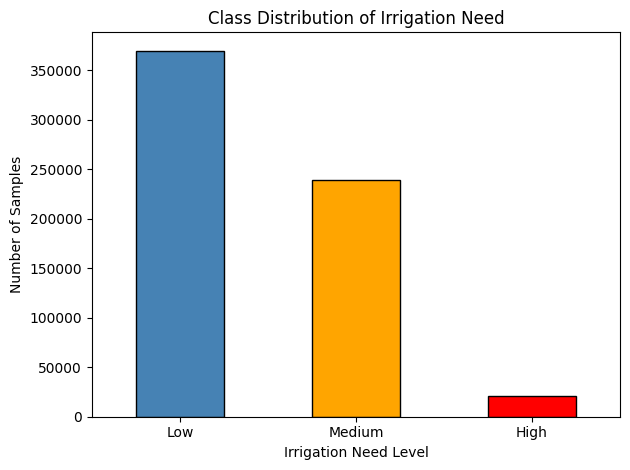

In [35]:
#VISUALIZE DA DATA (BECOME ONE WITH DA DATA)
train['Irrigation_Need'].value_counts().plot(
    kind='bar', color=['steelblue', 'orange', 'red'], edgecolor='black'
)
plt.title("Class Distribution of Irrigation Need")
plt.xlabel("Irrigation Need Level")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('class_distribution.png') 
plt.show()

In [36]:
#PREPROCESS DA DATA (GET IT READY FOR DA MODEL)
X = train.drop(columns=['id', 'Irrigation_Need'])
y = train['Irrigation_Need']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", le.classes_) 

cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

oe = OrdinalEncoder()
X[cat_cols] = oe.fit_transform(X[cat_cols])

X_test = test.drop(columns=['id'])
X_test[cat_cols] = oe.transform(X_test[cat_cols]) 

X_train, X_val, y_train, y_val = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f"Training samples:   {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples:       {X_test.shape[0]}")

Classes: ['High' 'Low' 'Medium']
Training samples:   504000
Validation samples: 126000
Test samples:       270000


In [37]:
#HELPER FUNCTION TO AVOID REPEATING CODE
def evaluate_model(model, X_val, y_val, model_name):
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    
    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"Validation Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print()
    print(classification_report(y_val, y_pred, target_names=le.classes_))
    
    return acc, y_pred

In [38]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_train_start = perf_counter()
dt.fit(X_train, y_train)
dt_train_time = perf_counter() - dt_train_start

dt_acc, dt_preds = evaluate_model(dt, X_val, y_val, "Decision Tree")

cm_dt = confusion_matrix(y_val, dt_preds)
cm_dt_df = pd.DataFrame(cm_dt, index=le.classes_, columns=le.classes_)
print("Decision Tree Confusion Matrix (rows=true, cols=pred):")
print(cm_dt_df)

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
dt_cv_start = perf_counter()
cv_dt = cross_val_score(dt, X, y_enc, cv=kf, scoring='accuracy', n_jobs=-1)
dt_cv_time = perf_counter() - dt_cv_start
print(f"K-Fold CV Accuracy: {cv_dt.mean():.4f} ± {cv_dt.std():.4f}")
print(f"Individual folds: {cv_dt.round(4)}")
print(f"Training time (split fit): {dt_train_time:.2f}s")
print(f"CV time: {dt_cv_time:.2f}s")


  Decision Tree
Validation Accuracy: 0.9854 (98.54%)

              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

Decision Tree Confusion Matrix (rows=true, cols=pred):
        High    Low  Medium
High    3878      0     324
Low        0  73646     337
Medium   182   1000   46633
K-Fold CV Accuracy: 0.9846 ± 0.0001
Individual folds: [0.9845 0.9847 0.9846]
Training time (split fit): 3.97s
CV time: 7.87s


In [39]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb_train_start = perf_counter()
nb.fit(X_train, y_train)
nb_train_time = perf_counter() - nb_train_start

nb_acc, nb_preds = evaluate_model(nb, X_val, y_val, "Naive Bayes")

cm_nb = confusion_matrix(y_val, nb_preds)
cm_nb_df = pd.DataFrame(cm_nb, index=le.classes_, columns=le.classes_)
print("Naive Bayes Confusion Matrix (rows=true, cols=pred):")
print(cm_nb_df)

nb_cv_start = perf_counter()
cv_nb = cross_val_score(nb, X, y_enc, cv=kf, scoring='accuracy', n_jobs=-1)
nb_cv_time = perf_counter() - nb_cv_start
print(f"K-Fold CV Accuracy: {cv_nb.mean():.4f} ± {cv_nb.std():.4f}")
print(f"Individual folds: {cv_nb.round(4)}")
print(f"Training time (split fit): {nb_train_time:.2f}s")
print(f"CV time: {nb_cv_time:.2f}s")


  Naive Bayes
Validation Accuracy: 0.8275 (82.75%)

              precision    recall  f1-score   support

        High       0.72      0.42      0.53      4202
         Low       0.85      0.90      0.88     73983
      Medium       0.79      0.75      0.77     47815

    accuracy                           0.83    126000
   macro avg       0.79      0.69      0.73    126000
weighted avg       0.82      0.83      0.82    126000

Naive Bayes Confusion Matrix (rows=true, cols=pred):
        High    Low  Medium
High    1778     23    2401
Low        4  66700    7279
Medium   685  11341   35789
K-Fold CV Accuracy: 0.8269 ± 0.0006
Individual folds: [0.8273 0.826  0.8274]
Training time (split fit): 0.18s
CV time: 3.14s


In [ ]:
#K-Means
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, random_state=42, n_init=10)
km_train_start = perf_counter()
km.fit(X_train)
km_train_time = perf_counter() - km_train_start

cluster_labels = np.zeros_like(km.labels_)
for cluster in range(3):
    mask = km.labels_ == cluster
    cluster_labels[cluster] = np.bincount(y_train[mask]).argmax()

val_clusters = km.predict(X_val)
km_preds = np.array([cluster_labels[c] for c in val_clusters])
km_acc = accuracy_score(y_val, km_preds)

print(f"\n{'='*50}")
print("  K-Means (as Classifier)")
print(f"{'='*50}")
print(f"Validation Accuracy: {km_acc:.4f} ({km_acc*100:.2f}%)")
print()
print(classification_report(y_val, km_preds, target_names=le.classes_))

cm_km = confusion_matrix(y_val, km_preds)
cm_km_df = pd.DataFrame(cm_km, index=le.classes_, columns=le.classes_)
print("K-Means Confusion Matrix (rows=true, cols=pred):")
print(cm_km_df)

cv_km = None
km_cv_time = np.nan

print(f"Training time (split fit): {km_train_time:.2f}s")
print("CV time: N/A since it's unsupervised")


  K-Means (as Classifier)
Validation Accuracy: 0.5872 (58.72%)

              precision    recall  f1-score   support

        High       0.00      0.00      0.00      4202
         Low       0.59      1.00      0.74     73983
      Medium       0.00      0.00      0.00     47815

    accuracy                           0.59    126000
   macro avg       0.20      0.33      0.25    126000
weighted avg       0.34      0.59      0.43    126000

K-Means Confusion Matrix (rows=true, cols=pred):
        High    Low  Medium
High       0   4202       0
Low        0  73983       0
Medium     0  47815       0
K-Fold CV Accuracy: N/A (K-Means is unsupervised)
Individual folds: N/A
Training time (split fit): 1.51s
CV time: N/A


In [41]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

# Use a faster solver configuration for large datasets
lr = LogisticRegression(max_iter=300, solver='saga', tol=1e-3, random_state=42)
lr_train_start = perf_counter()
lr.fit(X_train, y_train)
lr_train_time = perf_counter() - lr_train_start

lr_acc, lr_preds = evaluate_model(lr, X_val, y_val, "Logistic Regression")

cm_lr = confusion_matrix(y_val, lr_preds)
cm_lr_df = pd.DataFrame(cm_lr, index=le.classes_, columns=le.classes_)
print("Logistic Regression Confusion Matrix (rows=true, cols=pred):")
print(cm_lr_df)

lr_cv_start = perf_counter()
cv_lr = cross_val_score(lr, X, y_enc, cv=kf, scoring='accuracy', n_jobs=-1)
lr_cv_time = perf_counter() - lr_cv_start
print(f"K-Fold CV Accuracy: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}")
print(f"Individual folds: {cv_lr.round(4)}")
print(f"Training time (split fit): {lr_train_time:.2f}s")
print(f"CV time: {lr_cv_time:.2f}s")


  Logistic Regression
Validation Accuracy: 0.7462 (74.62%)

              precision    recall  f1-score   support

        High       0.62      0.23      0.34      4202
         Low       0.79      0.84      0.81     73983
      Medium       0.67      0.65      0.66     47815

    accuracy                           0.75    126000
   macro avg       0.69      0.57      0.60    126000
weighted avg       0.74      0.75      0.74    126000

Logistic Regression Confusion Matrix (rows=true, cols=pred):
        High    Low  Medium
High     986     80    3136
Low       20  62148   11815
Medium   590  16341   30884
K-Fold CV Accuracy: 0.7458 ± 0.0004
Individual folds: [0.7463 0.7453 0.7457]
Training time (split fit): 130.50s
CV time: 134.15s


In [42]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_train_start = perf_counter()
rf.fit(X_train, y_train)
rf_train_time = perf_counter() - rf_train_start

rf_acc, rf_preds = evaluate_model(rf, X_val, y_val, "Random Forest")

cm_rf = confusion_matrix(y_val, rf_preds)
cm_rf_df = pd.DataFrame(cm_rf, index=le.classes_, columns=le.classes_)
print("Random Forest Confusion Matrix (rows=true, cols=pred):")
print(cm_rf_df)

rf_cv_start = perf_counter()
cv_rf = cross_val_score(rf, X, y_enc, cv=kf, scoring='accuracy', n_jobs=-1)
rf_cv_time = perf_counter() - rf_cv_start
print(f"K-Fold CV Accuracy: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"Individual folds: {cv_rf.round(4)}")
print(f"Training time (split fit): {rf_train_time:.2f}s")
print(f"CV time: {rf_cv_time:.2f}s")


  Random Forest
Validation Accuracy: 0.9857 (98.57%)

              precision    recall  f1-score   support

        High       0.96      0.92      0.94      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.98      0.98     47815

    accuracy                           0.99    126000
   macro avg       0.98      0.96      0.97    126000
weighted avg       0.99      0.99      0.99    126000

Random Forest Confusion Matrix (rows=true, cols=pred):
        High    Low  Medium
High    3875      0     327
Low        0  73633     350
Medium   166    961   46688
K-Fold CV Accuracy: 0.9850 ± 0.0001
Individual folds: [0.9851 0.9849 0.985 ]
Training time (split fit): 113.97s
CV time: 224.70s


In [43]:
# LOOCV is too slow on half a million rows, so we run it on a sample
X_sample = X.sample(500, random_state=42)
y_sample = y_enc[X_sample.index]

loocv = LeaveOneOut()
loocv_scores = cross_val_score(
    DecisionTreeClassifier(max_depth=10, random_state=42),
    X_sample, y_sample, cv=loocv, scoring='accuracy'
)
print(f"LOOCV Accuracy (on 500-sample subset): {loocv_scores.mean():.4f}")
print("Note: LOOCV run on a 500-row sample due to computational limits")

LOOCV Accuracy (on 500-sample subset): 0.9080
Note: LOOCV run on a 500-row sample due to computational limits


              Model Validation Accuracy K-Fold CV Mean Display Train Time (s) CV Time Display Total Time (s)
      Decision Tree              0.9854                 0.9846          3.97s           7.87s         11.84s
        Naive Bayes              0.8275                 0.8269          0.18s           3.14s          3.32s
            K-Means              0.5872                    N/A          1.51s             N/A          1.51s
Logistic Regression              0.7462                 0.7458        130.50s         134.15s        264.65s
      Random Forest              0.9857                 0.9850        113.97s         224.70s        338.67s

Recommendation for retraining on full data:
- Best overall: Decision Tree (Val Acc=0.9854, CV Mean=0.9846, Total Time=11.84s)


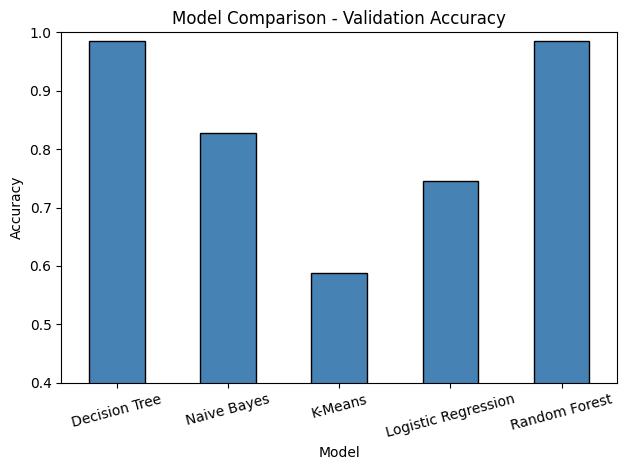

In [44]:
#Compare Da Models
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Naive Bayes', 'K-Means',
              'Logistic Regression', 'Random Forest'],
    'Validation Accuracy': [dt_acc, nb_acc, km_acc, lr_acc, rf_acc],
    'K-Fold CV Mean': [cv_dt.mean(), cv_nb.mean(), np.nan, cv_lr.mean(), cv_rf.mean()],
    'K-Fold CV Std': [cv_dt.std(), cv_nb.std(), np.nan, cv_lr.std(), cv_rf.std()],
    'Train Time (s)': [dt_train_time, nb_train_time, km_train_time, lr_train_time, rf_train_time],
    'CV Time (s)': [dt_cv_time, nb_cv_time, km_cv_time, lr_cv_time, rf_cv_time],
})

results['Total Time (s)'] = results['Train Time (s)'] + results['CV Time (s)'].fillna(0)
results['K-Fold CV Mean Display'] = results['K-Fold CV Mean'].map(lambda x: 'N/A' if pd.isna(x) else f"{x:.4f}")
results['CV Time Display'] = results['CV Time (s)'].map(lambda x: 'N/A' if pd.isna(x) else f"{x:.2f}s")

display_cols = [
    'Model', 'Validation Accuracy', 'K-Fold CV Mean Display',
    'Train Time (s)', 'CV Time Display', 'Total Time (s)'
]

results_print = results[display_cols].copy()
results_print['Validation Accuracy'] = results_print['Validation Accuracy'].map(lambda x: f"{x:.4f}")
results_print['Train Time (s)'] = results_print['Train Time (s)'].map(lambda x: f"{x:.2f}s")
results_print['Total Time (s)'] = results_print['Total Time (s)'].map(lambda x: f"{x:.2f}s")

results_sorted = results.sort_values(['Validation Accuracy', 'Total Time (s)'], ascending=[False, True]).reset_index(drop=True)
print(results_print.to_string(index=False))

candidate_models = results[results['K-Fold CV Mean'].notna()].copy()

def minmax(series):
    span = series.max() - series.min()
    if span == 0:
        return pd.Series([1.0] * len(series), index=series.index)
    return (series - series.min()) / span

candidate_models['score_acc'] = minmax(candidate_models['Validation Accuracy'])
candidate_models['score_cv'] = minmax(candidate_models['K-Fold CV Mean'])
candidate_models['score_time'] = 1 - minmax(candidate_models['Total Time (s)'])
candidate_models['overall_score'] = (
    0.45 * candidate_models['score_cv'] +
    0.35 * candidate_models['score_acc'] +
    0.20 * candidate_models['score_time']
    )

best_row = candidate_models.sort_values('overall_score', ascending=False).iloc[0]
recommended_model_name = best_row['Model']

print("\nRecommendation for retraining on full data:")
print(
    f"- Best overall: {recommended_model_name} "
    f"(Val Acc={best_row['Validation Accuracy']:.4f}, "
    f"CV Mean={best_row['K-Fold CV Mean']:.4f}, "
    f"Total Time={best_row['Total Time (s)']:.2f}s)"
    )

results.plot(x='Model', y='Validation Accuracy', kind='bar',
             legend=False, color='steelblue', edgecolor='black')
plt.title("Model Comparison - Validation Accuracy")
plt.ylabel("Accuracy")
plt.ylim(0.4, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

In [47]:
# Retrain Decision Tree on ALL training data
from sklearn.tree import DecisionTreeClassifier

print("Retraining Decision Tree on full dataset...")
final_model = DecisionTreeClassifier(max_depth=10, random_state=42)

full_train_start = perf_counter()
final_model.fit(X, y_enc)
full_train_time = perf_counter() - full_train_start

test_preds = final_model.predict(X_test)
test_preds_labels = le.inverse_transform(test_preds)

submission = pd.DataFrame({
    'id': test['id'],
    'Irrigation_Need': test_preds_labels
})
submission.to_csv('submission.csv', index=False)

print("submission.csv created!")
print(f"Full-data training time: {full_train_time:.2f}s")
print(submission['Irrigation_Need'].value_counts())
submission

Retraining Decision Tree on full dataset...
submission.csv created!
Full-data training time: 8.90s
Irrigation_Need
Low       159909
Medium    101371
High        8720
Name: count, dtype: int64


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
...,...,...
269995,899995,Medium
269996,899996,Low
269997,899997,Medium
269998,899998,Low
